# Telecomunicaciones: identificar operadores ineficaces

### Introducción

 El servicio de telefonía virtual CallMeMaybe está desarrollando una nueva función que brindará a los supervisores y las supervisores información sobre los operadores menos eficaces. Se considera que un operador es ineficaz si tiene una gran cantidad de llamadas entrantes perdidas (internas y externas) y un tiempo de espera prolongado para las llamadas entrantes. Además, si se supone que un operador debe realizar llamadas salientes, un número reducido de ellas también será un signo de ineficacia.

#### Objetivos
Para poder determinar qué es un operador ineficaz, primero debemos clarificar:

- Cuál es el mínimo de número de llamadas salientes por día.
- Cuál es un tiempo de espera prolongado.
- Determinar cuantas se consideran una 'gran cantidad de llamadas entrantes perdidas (internas y externas)'.


Teniendo claro estos criterios podremos identificar los operadores ineficaces.


Luego pondremos a prueba la hipótesis: 

<i>'El porcentaje de operadores ineficaces es igual en los tres tipos de tarifa'. </i>

### Etapa 1: Descripción de los datos

Los datasets contienen información sobre el uso del servicio de telefonía virtual CallMeMaybe. Sus clientes son organizaciones que necesitan distribuir gran cantidad de llamadas entrantes entre varios operadores, o realizar llamadas salientes a través de sus operadores. Los operadores también pueden realizar llamadas internas para comunicarse entre ellos. Estas llamadas se realizan a través de la red de CallMeMaybe.

#### Diccionario de datos

El dataset `telecom_dataset_us.csv` contiene las siguientes columnas:

- `user_id`: ID de la cuenta de cliente
- `date`: fecha en la que se recuperaron las estadísticas
- `direction`: "dirección" de llamada (`out` para saliente, `in` para entrante)
- `internal`: si la llamada fue interna (entre los operadores de un cliente o clienta)
- `operator_id`: identificador del operador
- `is_missed_call`: si fue una llamada perdida
- `calls_count`: número de llamadas
- `call_duration`: duración de la llamada (sin incluir el tiempo de espera)
- `total_call_duration`: duración de la llamada (incluido el tiempo de espera)


El conjunto de datos `telecom_clients_us.csv` tiene las siguientes columnas:

- `user_id`: ID de usuario/a
- `tariff_plan`: tarifa actual de la clientela
- `date_start`: fecha de registro de la clientela

In [1434]:
#Importamos librerías

import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import scipy.stats as st
import math as mth

In [1435]:
#Leemos y almacenamos los datasets

clients = pd.read_csv('documents/telecom_clients_us.csv')
data = pd.read_csv('documents/telecom_dataset_us.csv')

In [1436]:
#información general de data
print(data.info())

#primeras 5 filas de data
display(data.sample(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB
None


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
47591,168187,2019-10-25 00:00:00+03:00,in,False,937762.0,False,3,197,237
33924,167497,2019-11-01 00:00:00+03:00,out,False,924948.0,True,2,0,44
19231,166983,2019-10-24 00:00:00+03:00,out,False,901880.0,True,6,0,198
4866,166511,2019-10-22 00:00:00+03:00,out,False,891416.0,False,14,2163,2293
21030,167016,2019-10-30 00:00:00+03:00,out,True,NaN,True,1,0,11


Como primera observación se ven varios datos almacenados de manera incorrecta: 
- user_id, operator_id van a ser transformados a string, los datos son de tipo interger cuando necesitamos realizar operaciones matemáticas con los mismos.
- date: aparece como object y debe ser transformado al tipo datetime
- direction: vamos a utilizar la función de pandas get_dummies()
- internal: las salidas deben ser tratadas como datos booleanos

Además se observan datos nulos en las columnas de 'internal' y 'operator_id'.

Teniendo en cuenta los números en la columna de duración de las llamadas los mismos se consideran duración en segundos.
También se va a crear la columna waiting-time para saber cuanto tiempo de espera hay.

In [1437]:
#obtengo informacion general de clients
print(clients.info())

#primeras 5 filas de clients
display(clients.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB
None


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


Se van a transformar el tipo de datos de la columna 'user_id' al tipo string y de date_star al tipo datetime.

No se observan datos nulos.

### Etapa 2: Pre-procesamiento de Datos

Teniendo en cuanta lo observado hasta el momento, se va a crear un nuevo dataset donde podamos trabajar con los datos limpios

In [1438]:
#observamos nulos y duplicados en clients
print('cantidad de datos duplicados en Clients:', clients.duplicated().sum())
print('cantidad de datos nulos en Clients:')
print(clients.isnull().sum())

cantidad de datos duplicados en Clients: 0
cantidad de datos nulos en Clients:
user_id        0
tariff_plan    0
date_start     0
dtype: int64


In [1439]:
#renombramos tariff_plan a más simple
clients = clients.rename(columns={'tariff_plan': 'plan'})

In [1440]:
#hacemos una copia del dataset original para trabajar con los datos limpios
clean_data = data.copy()

In [1441]:
#observamos cantidad de datos nulos y duplicados en data
print('cantidad de datos nulos en Data:')
print(clean_data.isnull().sum())
print('cantidad de datos duplicados en Data:', clean_data.duplicated().sum())

cantidad de datos nulos en Data:
user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64
cantidad de datos duplicados en Data: 4900


Existen 4900 datos duplicados en el DF de 'data', los mismos van a ser eliminados, porque no me sirven al momento de analizar.


En cuanto a datos nulos se observan 117 en la columna 'internal' del DF 'data', y en la columna 'operator_id' 8172, vamos a ver qué sucede al eliminar los duplicados y si se observa alguna razón por la cual existen tantos datos nulos en esta última columna.

In [1442]:
#Eliminamos los datos duplicados porque su cantidad no es significativa
clean_data = clean_data.drop_duplicates().reset_index(drop=True)

#confirmo que se hayan eliminado
print('cantidad de datos duplicados en Data:', clean_data.duplicated().sum())

cantidad de datos duplicados en Data: 0


In [1443]:
#cambiamos el tipo de dato de 'user_id' y 'operator_id' a string
clean_data['user_id'] = clean_data['user_id'].astype(str)
clients['user_id'] = clients['user_id'].astype(str)

#cambiamos el tipo de dato de la columna 'date' y 'date_start' a formato fecha
clean_data['date'] = pd.to_datetime(clean_data['date'])
clients['date_start'] = pd.to_datetime(clients['date_start'])

#la hora es siempre 00:00:00 en la columna 'date'. Para poder observar mejor los datos, vamos a remover la hora
clean_data['date'] = clean_data['date'].dt.date
clients['date_start'] = clients['date_start'].dt.date


#cambiamos el tipo de dato de la columna 'internal' a booleano
clean_data['internal'] = clean_data['internal'].astype(bool)

In [1444]:
#creamos columna 'wainting_time' para saber el tiempo de espera

clean_data['waiting_time'] = clean_data['total_call_duration'] - clean_data['call_duration']

In [1445]:
#observamos los datos nulos es la columna 'operator_id' para ver si hay algún dato en alguna de las otra columnas que nos de una razón
#por la cuál operator_id está nulo
display(clean_data[clean_data['operator_id'].isna()].sample(5))

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time
19844,167052,2019-09-21,in,False,NaN,True,1,0,26,26
30116,167479,2019-11-13,in,False,NaN,True,8,0,228,228
5272,166536,2019-10-03,in,False,NaN,True,1,0,1,1
32530,167543,2019-10-10,in,False,NaN,True,5,0,28,28
32560,167545,2019-09-27,in,False,NaN,True,1,0,2,2


In [1446]:
#observamos los datos no nulos en la columna 'operator_id' para comparar con los que están nulos
display(clean_data[clean_data['operator_id'].notnull()].sample(5))

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time
11593,166782,2019-09-03,in,False,899250.0,False,9,529,597,68
1969,166406,2019-11-01,out,False,879898.0,False,7,292,385,93
41990,168091,2019-11-18,out,False,958468.0,False,38,3096,3613,517
45551,168252,2019-10-22,in,True,940568.0,False,1,90,100,10
14192,166901,2019-08-28,in,False,896014.0,False,1,9,24,15


In [1447]:
#observamos si los user_id que están tienen un operador identificado (operator_id) están en los que no lo poseen, y ver si esto genera el 
#fallo al registrar 'operator_id'. Utilizamos un ciclo for que devuelva los nombres que si están

#empezamos un contador en 0 para saber cantidad de usuarios encontrados
users_found = 0

for user in clean_data[clean_data['operator_id'].isnull()]['user_id'].unique():
    if user in clean_data[clean_data['operator_id'].notnull()]['user_id'].unique():
        users_found = users_found +1
print('usuarios encontrados:', users_found)


usuarios encontrados: 288


Como se puede observar, los user_id aparecen en tanto cuando hay operadores identificados como cuando son nulos.
vamos a hacer un merge de los 2 DFs para ver si se encuentra algún otra razón, aunque no debería.

In [1448]:
clean_data = clean_data.merge(clients, on='user_id', how='left')

In [1449]:
#reordenamos las columnas para que sea más fácil de leer

clean_data = clean_data.iloc[:, [0, 10, 11, 1, 2, 3, 4, 5, 6, 7, 8, 9]]

In [1450]:
#Volvemos a observar los datos nulos es la columna 'operator_id' para ver si hay algún dato en alguna de las otra columnas que nos de una razón
#por la cuál operator_id está nulo
display(clean_data[clean_data['operator_id'].isna()].sample(5))

,user_id,plan,date_start,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time
38831,167976,C,2019-10-08,2019-11-13,in,False,NaN,True,1,0,31,31
47587,168361,A,2019-10-23,2019-11-06,in,False,NaN,True,1289,0,6534,6534
32034,167521,B,2019-09-19,2019-11-22,in,False,NaN,True,32,0,722,722
46536,168271,C,2019-10-18,2019-11-10,in,False,NaN,True,7,0,154,154
17992,166993,C,2019-08-28,2019-09-26,in,False,NaN,True,1,0,4,4


In [1451]:
#Nuevamente observamos los datos no nulos en la columna 'operator_id' para comparar con los que están nulos
display(clean_data[clean_data['operator_id'].notnull()].sample(5))

,user_id,plan,date_start,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time
33751,167626,A,2019-09-24,2019-10-08,out,False,919376.0,True,40,0,1256,1256
36985,167827,C,2019-10-02,2019-10-30,in,False,929424.0,False,9,103,113,10
42708,168154,B,2019-10-15,2019-11-14,in,False,939370.0,False,28,2267,3142,875
15605,166916,A,2019-08-23,2019-11-20,out,True,906400.0,True,1,0,0,0
30344,167487,B,2019-09-18,2019-11-21,in,False,940968.0,False,1,6,20,14


No puedo observar una razón clara por la que operador_id quede como un dato nulo.

Vamos a reemplazar nulos por 0 para que sea fácil de identificar y luego convertirlo a string para que al momento de realizar análisis no se vea afectado

In [1452]:
clean_data['operator_id'] = clean_data['operator_id'].fillna(0)

#Filtramos el DF con los operadores registrados, ya que pueden interferir en las estadísticas al unificar los datos nulos en un solo operador
clean_data = clean_data[clean_data['operator_id'] > 0]


#transformamos el tipo de dato
clean_data['operator_id'] = clean_data['operator_id'].astype(str)
print('Cantidad de operadores únicos registrados:', clean_data['operator_id'].nunique())


Cantidad de operadores únicos registrados: 1092


### Etapa 3: EDA, Análisis Exploratorio de Datos

In [1453]:
#obtengo informacion estadística general de data
display(clean_data.describe())

,calls_count,call_duration,total_call_duration,waiting_time
count,41546.000000,41546.000000,41546.000000,41546.000000
mean,16.900424,1009.769172,1321.592813,311.823641
std,59.749373,4064.106117,4785.978633,1175.373073
min,1.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,67.000000,19.000000
50%,4.000000,106.000000,288.000000,60.000000
75%,13.000000,770.000000,1104.000000,219.000000
max,4817.000000,144395.000000,166155.000000,46474.000000


En rasgos generales, hasta el 75%, el número de llamadas es 13, aunque la mediana es 4 y el promedio es de casi 17. Aunque el número máximo pareciera ser totalmente anómalo: 4817.

En cuanto a duración de llamadas, lo mismo, la mediana es de 106 segundos, la media es 1009 y el máximo es de 144395 segundos. 

Pasa igual con el tiempo de espera: una media de 311, pero con una mediana de 60. Puede que esto se deba a datos anómalos, pero vamos a analizar esto.

In [1454]:
#observamos durante cuánto tiempo se han hecho estos registros:
print('Fecha de comienzo de registros:', clean_data['date'].min())
print('Fecha de finalización de registros:', clean_data['date'].max())


Fecha de comienzo de registros: 2019-08-02
Fecha de finalización de registros: 2019-11-28


Se puede observar que los registros son desde principios de agosto (2) a finales de noviembre (28) 2019, es decir 4 meses en total.

##### Cantidad de llamadas por operador

In [1455]:
#Observamos cómo se ven la cantidad de llamadas salientes, fuera de la empresa, por operador por día para identificar datos anómalos
#filtramos por llamadas salientes el DF
out_calls = clean_data[clean_data['direction'] == 'out']
out_calls = clean_data[clean_data['internal'] == False]

#Agrupamos por operador y fecha y calculamos cantidad de llamadas
out_calls = out_calls.groupby(['operator_id', 'date'])['calls_count'].sum().reset_index()
out_calls.columns = ['operador', 'fecha','llamadas']
out_calls.describe()

,llamadas
count,18641.000000
mean,36.930422
std,117.049791
min,1.000000
25%,2.000000
50%,9.000000
75%,34.000000
max,5022.000000


Sin duda hay datos anómalos que afecta al promedio de llamadas por usuario por día, ya que el 75% registra 35 llamadas, y el promedio dice ser 40 por operador y el máximo de más de 5000 llamadas. Graficaremos para observar mejor.


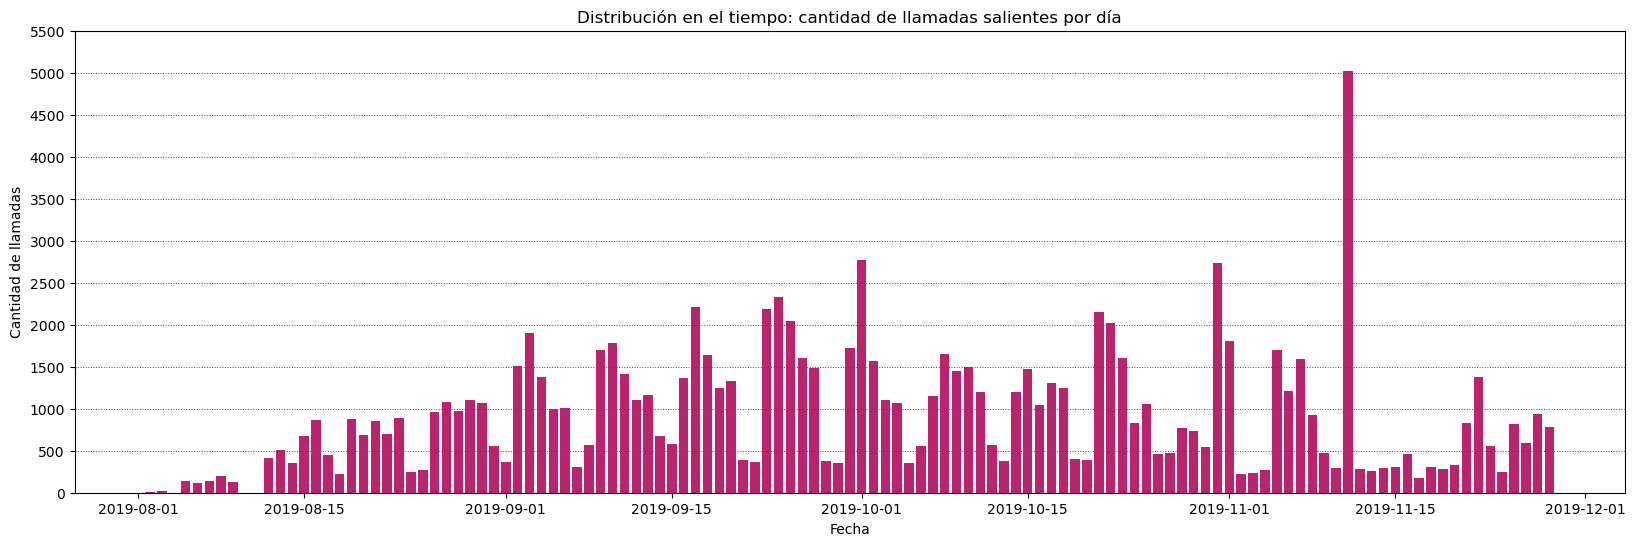

In [1456]:
#observemos como se ve en un gráfico de dispersión la cantidad de llamadas salientes por día
plt.figure(figsize=[20,6])
plt.title('Distribución en el tiempo: cantidad de llamadas salientes por día')
plt.bar(out_calls['fecha'], out_calls['llamadas'], color="#BB246D")
plt.xlabel('Fecha')
plt.ylabel('Cantidad de llamadas')
plt.yticks(range(0, 6000, 500))
plt.grid(axis='y', color='green', linestyle=':', linewidth=0.7)
plt.show()

A principios de Agosto, cuando recién comenzaba el registro de los datos, se observa menor cantidad de llamadas que en los días siguientes. Puede que aquí esté la causa de la cantidad de IDs no registrados por una falla técnica o error humano, como también combinación de ambas.

Existen días donde la cantidad de llamadas es menor a 500, asi como días que superan los 1000. Pero los días con más de 2000 llamadas salientes parecen ser poco usuales, como la fecha con más de 5000 llamadas salientes.

Distribución de la cantidad de llamadas salientes por operador por día


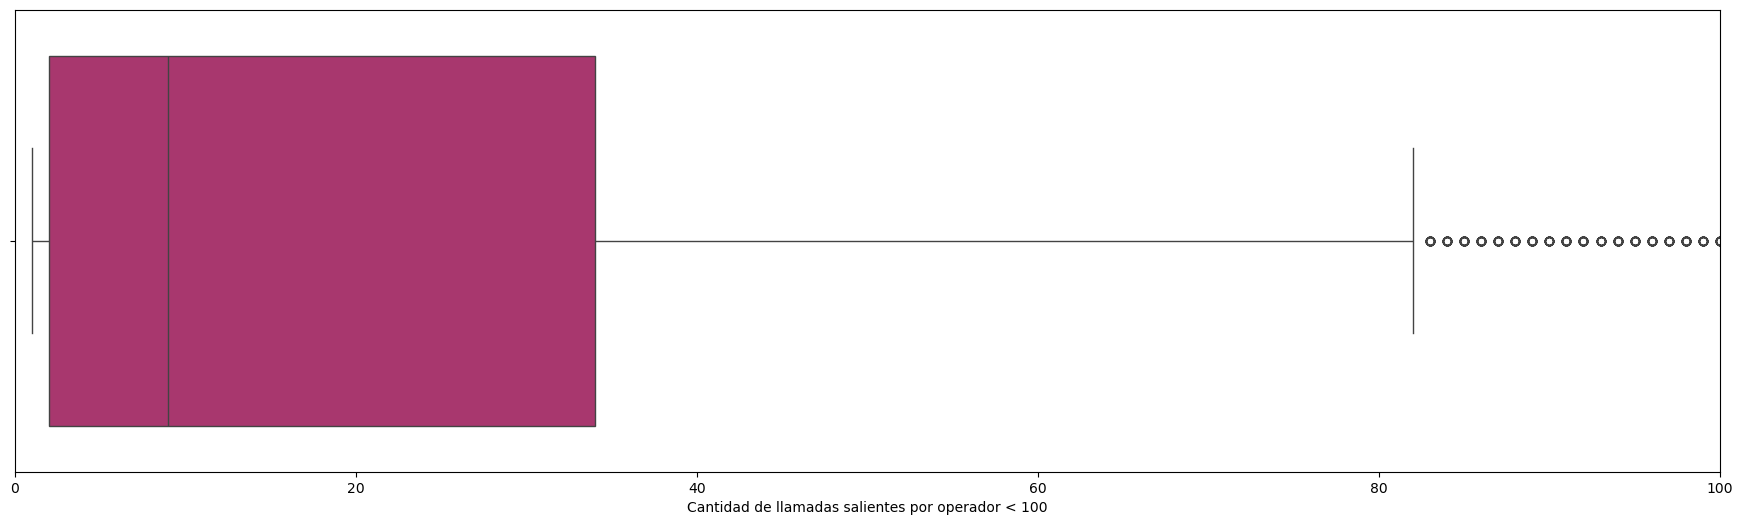

In [1457]:
# Vamos a graficar con Box que demuestra por cuartiles cantidad de llamadas por operador por día
print('Distribución de la cantidad de llamadas salientes por operador por día')
plt.figure(figsize=[22,6])
sns.boxplot(data=out_calls, x='llamadas', color="#BB246D")
plt.xlabel('Cantidad de llamadas salientes por operador < 100')
plt.xlim(0, 100)
plt.show()

Con boxplot se puede observar lo que vimos con describe(), todo operador que supere las 80 y pocas llamadas se consideran, por el momento, datos sesgados. Incluso, teniendo en cuenta que un operador trabaja 40hs a la semana, digamos 5 días, 8hs por día, hacer más de 80 llamadas significa que realiza llamadas cada 6 minutos. Esto podría además significar que no todos los usuarios/clientes atienden estas llamadas y por eso realiza tantas.

In [1458]:
#Observamos cómo se ven la cantidad de llamadas salientes, dentro de la empresa, por operador por día para identificar datos anómalos
#filtramos por llamadas salientes el DF
out_calls_internal = clean_data.query('direction == "out" & internal == True')

#Agrupamos por operador y fecha y calculamos cantidad de llamadas
out_calls_internal = out_calls_internal.groupby(['operator_id', 'date'])['calls_count'].sum().reset_index()
out_calls_internal.columns = ['operador', 'fecha','llamadas']
out_calls_internal.describe()

,llamadas
count,3771.000000
mean,3.440467
std,3.819446
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,89.000000


Se observa con describe que hay hasta un 75% de los operadores que realizan hasta 4 llamadas internal.
89 es un número anómalo. Graficamos para observar mejor

Distribución de la cantidad de llamadas salientes por operador por día dentro de la empresa


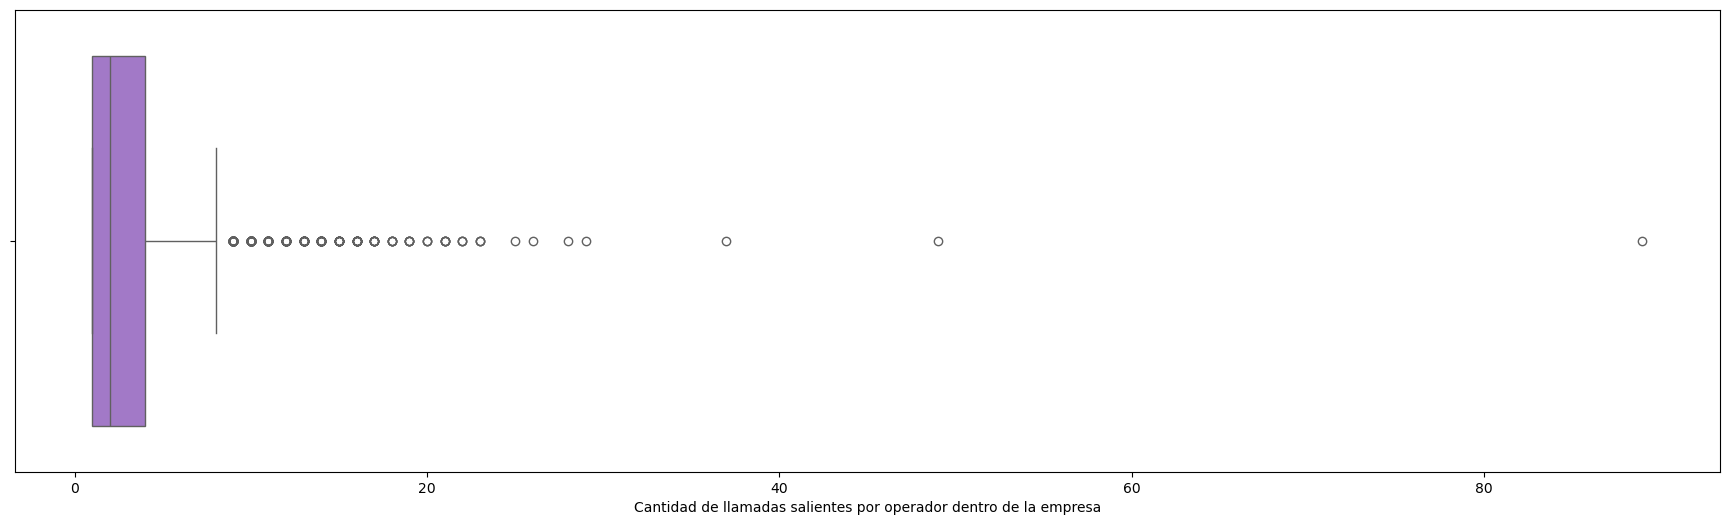

In [1459]:
print('Distribución de la cantidad de llamadas salientes por operador por día dentro de la empresa')
plt.figure(figsize=[22,6])
sns.boxplot(data=out_calls_internal, x='llamadas', color="#A36CD4")
plt.xlabel('Cantidad de llamadas salientes por operador dentro de la empresa')
plt.show()

Se confirma lo observado en describe(), lo que supere las 10 llamadas internas se consideran datos sesgados.

##### Duración promedio del tiempo de espera y duración de la llamada entrante

In [1460]:
#vamos a observar la duración promedio del tiempo de espera por operador y por fecha de las llamadas entrantes
waiting = clean_data[clean_data['direction'] == 'in']
waiting = waiting.groupby(['operator_id', 'date'])[['waiting_time', 'call_duration', 'total_call_duration']].mean().reset_index()
waiting.columns = ['operador', 'date', 'waiting_mean', 'duration', 'total']
display(waiting.describe())

,waiting_mean,duration,total
count,11781.000000,11781.000000,11781.000000
mean,94.740995,729.756387,824.497383
std,171.309996,1307.821461,1410.662673
min,0.000000,0.000000,2.500000
25%,18.000000,83.000000,111.000000
50%,41.000000,292.000000,343.000000
75%,99.000000,865.000000,967.000000
max,3998.000000,33897.000000,34280.000000


Se puede observar que hasta el 75% de los operadores tienen una espera promedio de 99 segundos: no llega a los 2 minutos. Y en la duracion de las llamadas hasta el 75% de 865 segundos: 14 minutos mas o menos. El total de la llamada, hasta el 75% suele ser de 16 minutos.

El promedio de espera es de 95 segundos: poco más de un minuto y medio, pero la mediana es de 41 segundos, es decir, menos de un minuto. En cuanto al promedio de duración de las llamadas es de 729 segundos, 12 minutos. Pero la mediana dice ser: 292 segundos, casi 5 minutos. En cuanto al total de la llamada la media dice ser 824 segundos casi 14 minutos, pero la mediana es de 343 segundos: casi 6 minutos.

El tiempo máximo promedio es de 3998 segundos, lo que corresponde a 66 minutos: más de una hora. El tiempo máximo promedio registrado en promedio de llamadas es de 33.897 segundos: 564,95 minutos, más de 9 horas. En cuanto al tiempo máximo de la duración total es de 34280 segundos: 571 minutos, más de 9hs y media. Datos anómalos afectan las estadísticas. Graficamos para observar mejor.


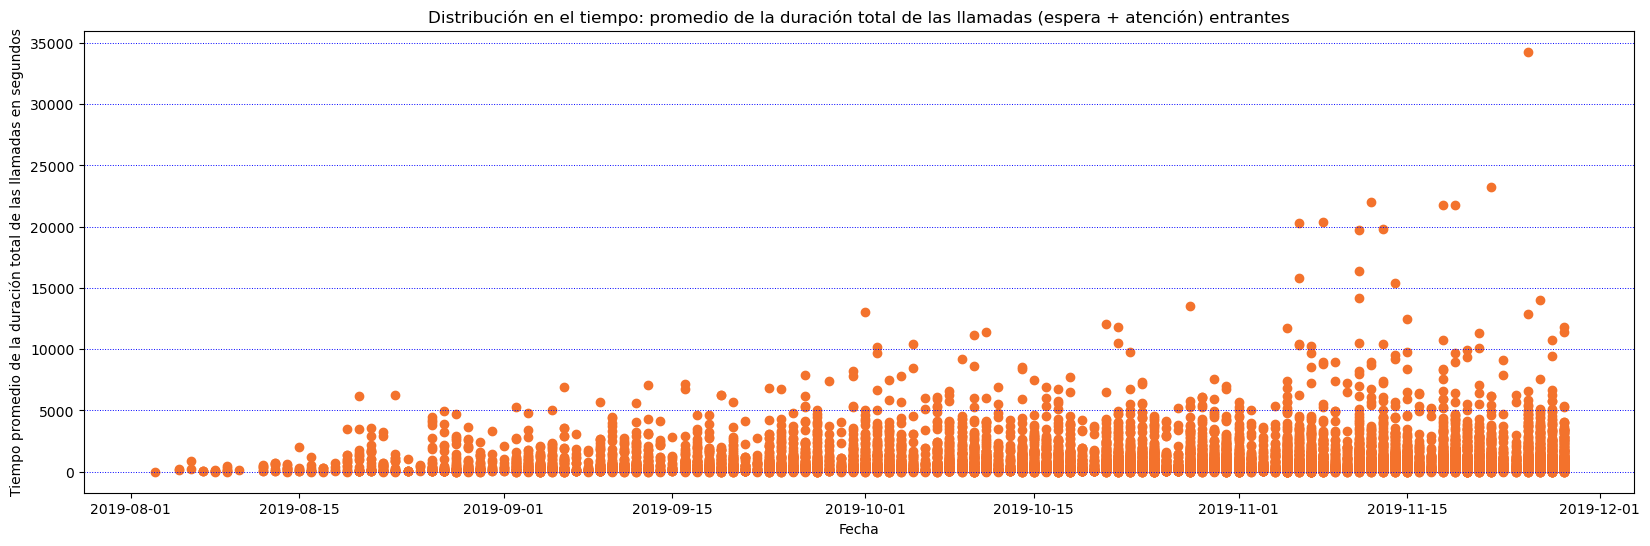

In [1461]:
#observemos como se ve en un gráfico de dispersión la duración promedio de las llamadas
plt.figure(figsize=[20,6])
plt.title('Distribución en el tiempo: promedio de la duración total de las llamadas (espera + atención) entrantes')
plt.scatter(waiting['date'], waiting['total'], color="#F3722C")
plt.xlabel('Fecha')
plt.ylabel('Tiempo promedio de la duración total de las llamadas en segundos')
plt.yticks(range(0, 40000, 5000))
plt.grid(axis='y', color='blue', linestyle=':', linewidth=0.7)
plt.show()

Podemos observar en este gráfico cómo se observa la duración total de la llamada por día. Las fechas donde se superan los 5000 son pocas, y las que superan los 10000 ya podrían considerarse anómalas.

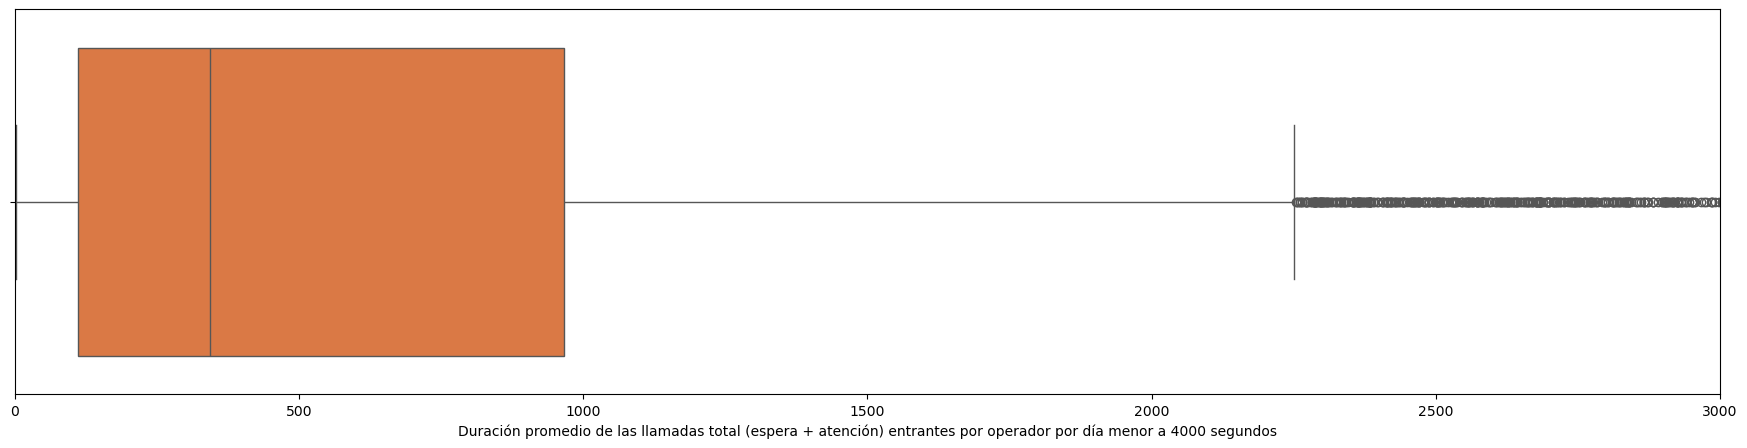

In [1462]:
plt.figure(figsize=[22,5])
sns.boxplot(data=waiting, x='total',color="#F3722C")

plt.xlabel('Duración promedio de las llamadas total (espera + atención) entrantes por operador por día menor a 4000 segundos')
plt.xlim(0, 3000)
plt.show()

Podemos ver como la mayoría de los registros, entre el cuartil 25 y el 75 se encuentran los 100 y los casi 1000 segundos para la duración promedio de la llamada en total: teniendo en cuenta tiempo de espera y duración de la llamada.

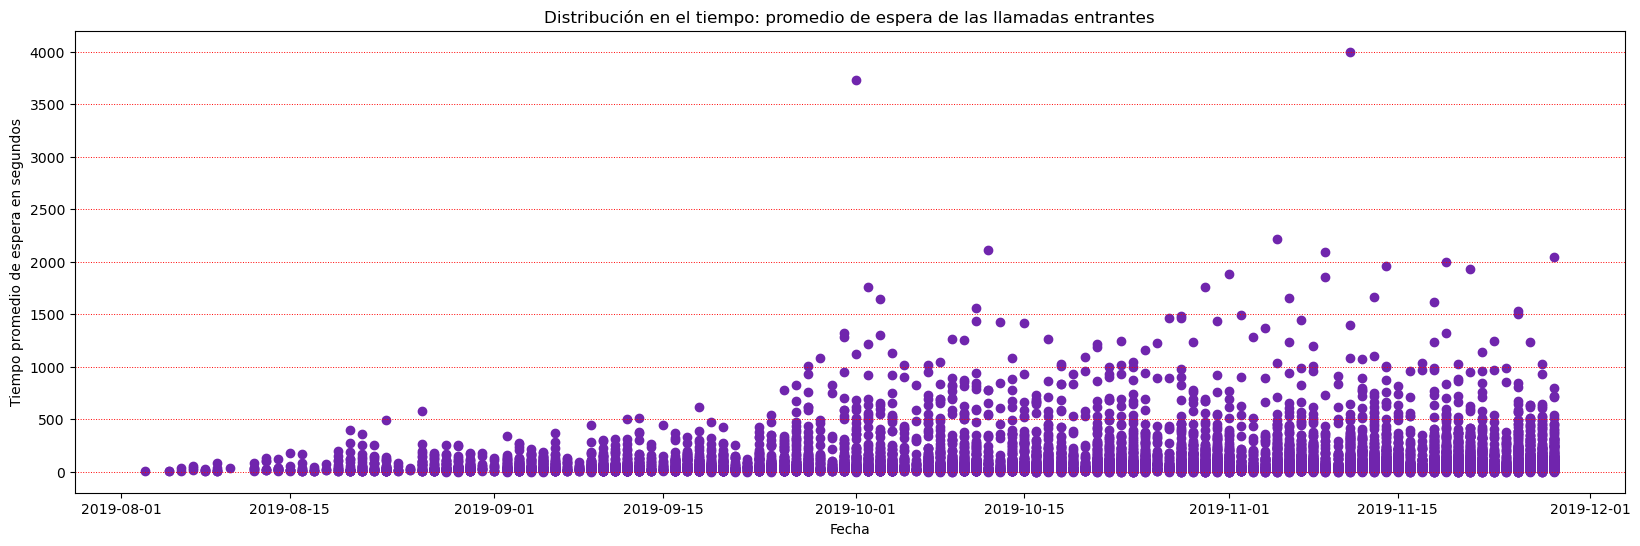

In [1463]:
#observemos como se ve en un gráfico de dispersión la distribución del promedio del tiempo de espera
plt.figure(figsize=[20,6])
plt.title('Distribución en el tiempo: promedio de espera de las llamadas entrantes')
plt.scatter(waiting['date'], waiting['waiting_mean'], color="#7025AD")
plt.xlabel('Fecha')
plt.ylabel('Tiempo promedio de espera en segundos')
plt.grid(axis='y', color='red', linestyle=':', linewidth=0.7)
plt.show()

Las fechas donde el tiempo de espera que supera los 500 segundos empiezan a notarse como sesgados en comparación con el resto de los días donde no superan dicho tiempo.

Distribución del tiempo promedio de espera de las llamadas entrantes por operador por día


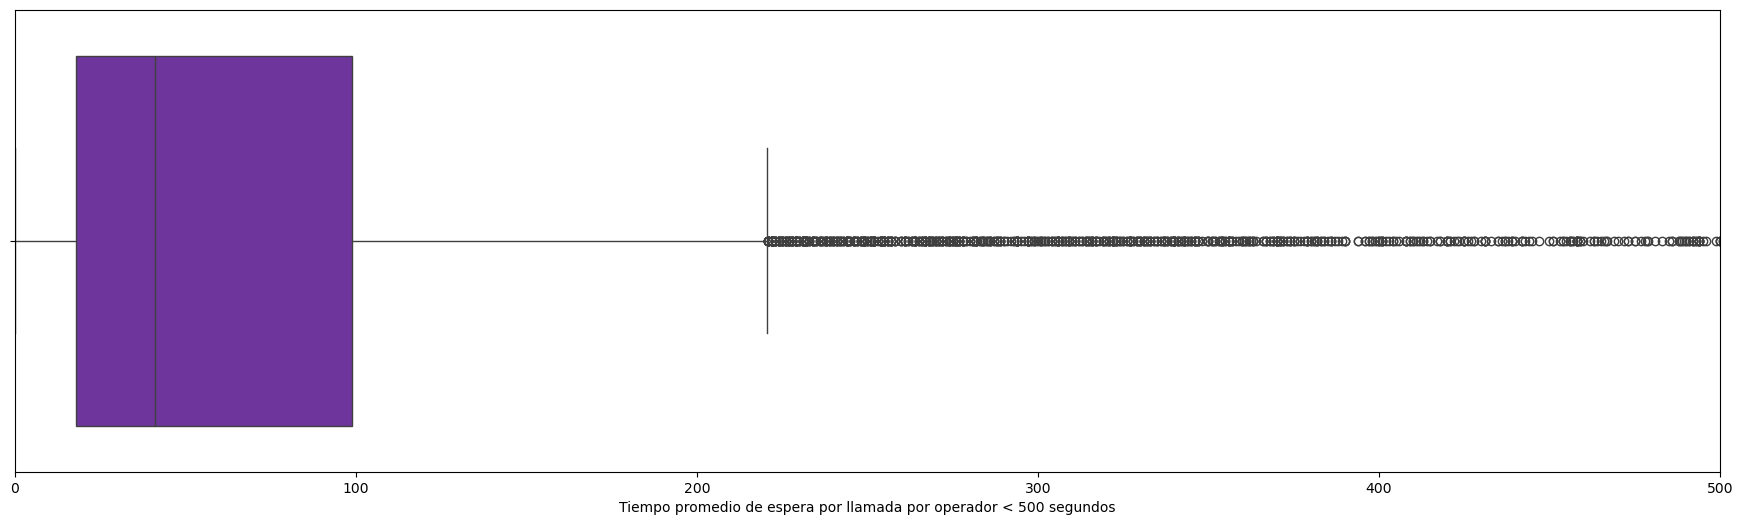

In [1464]:
print('Distribución del tiempo promedio de espera de las llamadas entrantes por operador por día')
plt.figure(figsize=[22,6])
sns.boxplot(data=waiting, x='waiting_mean', color="#7025AD")
plt.xlabel('Tiempo promedio de espera por llamada por operador < 500 segundos')
plt.xlim(0, 500)
plt.show()

El BoxPlot grafica lo visto con desbribe, donde las llamadas que superan los 200 segundos son considerados datos sesgados.

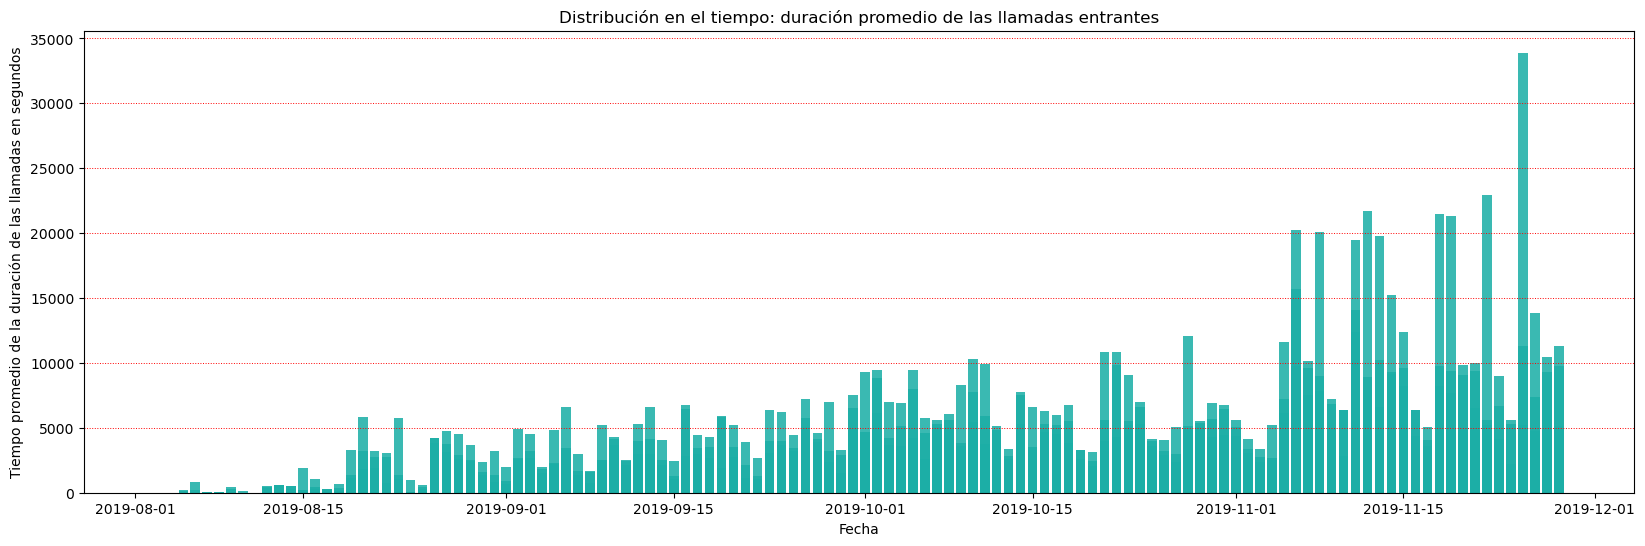

In [1465]:
#observemos como se ve en un gráfico de dispersión la duración promedio de las llamadas
plt.figure(figsize=[20,6])
plt.title('Distribución en el tiempo: duración promedio de las llamadas entrantes')
plt.bar(waiting['date'], waiting['duration'], color="#1CAEA6DD")
plt.xlabel('Fecha')
plt.ylabel('Tiempo promedio de la duración de las llamadas en segundos')
plt.grid(axis='y', color='red', linestyle=':', linewidth=0.7)
plt.show()



Teniendo en cuenta lo visto con describe, y lo que se observa en este gráfico de distribución del promedio de duración de llamadas, observamos que hay muchos datos anormales. Vamos a utilizar boxplot con un límite de 4000 segundos.

Distribución de la duración promedio de las llamadas entrantes por operador por día


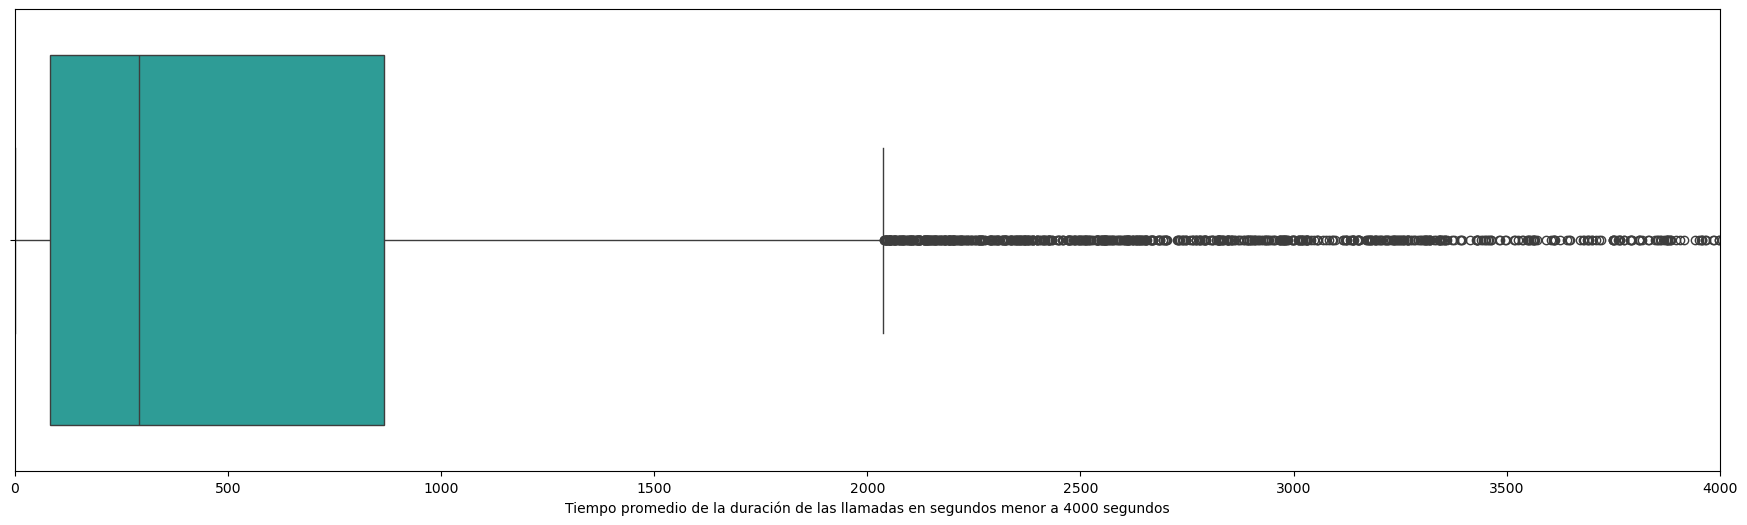

In [1466]:
print('Distribución de la duración promedio de las llamadas entrantes por operador por día')
plt.figure(figsize=[22,6])
sns.boxplot(data=waiting, x='duration', color="#1CAEA6DD")
plt.xlabel('Tiempo promedio de la duración de las llamadas en segundos menor a 4000 segundos')
plt.xlim(0, 4000)
plt.show()

Las llamadas con una duración promedio a los 2000 segundos se consideran un dato sesgado.

##### Cantidad de llamadas entrantes perdidas

In [1467]:
#Analizamos cantidad de llamadas entrantes perdidas

missed_calls = clean_data.query("is_missed_call == True")
missed_calls = missed_calls.groupby(['operator_id', 'date'])['is_missed_call'].count().reset_index()
display(missed_calls.describe())

,is_missed_call
count,12321.000000
mean,1.145199
std,0.367869
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,4.000000


Se puede leer con describe que el máximo de llamadas perdidas para un operador por día es 4 y la media es de 1 por operador por día, tanto de llamadas entrantes como salientes.

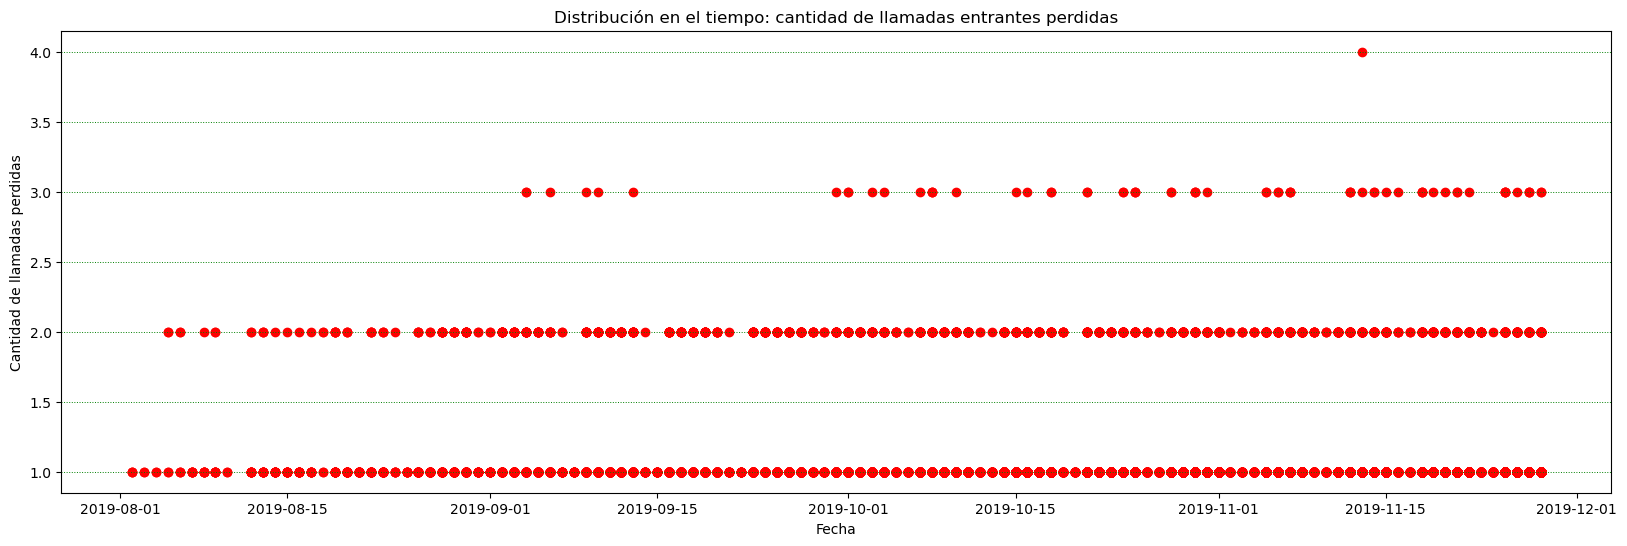

In [1468]:
#observemos como se ve en un gráfico de dispersión la duración promedio de las llamadas
plt.figure(figsize=[20,6])
plt.title('Distribución en el tiempo: cantidad de llamadas entrantes perdidas')
plt.scatter(missed_calls['date'], missed_calls['is_missed_call'], color="red")
plt.xlabel('Fecha')
plt.ylabel('Cantidad de llamadas perdidas')
plt.grid(axis='y', color='green', linestyle=':', linewidth=0.7)
plt.show()

##### Etapa 3.1 Identificar operadores ineficaces


Teniendo en cuenta lo analizado previamente, y fuentes externas, se establece que un operado eficaz cumple con:
- Cantidad de llamadas salientes fuera de la empresa: con un mínimo de  10, es decir, la mediana, y según lo estipulado en fuentes externas es entre 30-40.
- Tiempo de espera: menor a 99 segundos.
- Cantidad de llamadas entrantes perdidas: 1 o menos.

Para identificar a los operadores ineficaces vamos a filtrar los datos que poseemos, según estos criterios, todo lo que NO cumpla con estos tres requisitos se considerará un operador ineficaz. Además filtraremos los datos teniendo en cuenta que, en lo analizado anteriormente, hay muchos datos sesgados, como la duración promedio de las llamadas.

In [1469]:
#Primero vamos a crear un nuevo DF donde agrupamos por los datos que necesitamos analizar: 
# operador, fecha, dirección (nos sirve para filtrar por cantidad de 'out'calls, llamadas internas (tienen que ser menor a 10)
# cantidad de llamadas recibidas, cantidad de perdidas, tiempo promedio de espera y duración promedio de la llamada)
operador_data = clean_data.groupby(['operator_id', 'date', 'direction']).agg({'calls_count' : 'sum', 'is_missed_call': 'count' , 'call_duration' : 'mean', 'waiting_time' : 'mean'}).reset_index()
operador_data.columns = ['operador', 'fecha', 'in_out', 'cantidad', 'perdidas', 'duracion', 'espera']

#filtramos por duración de la llamada, donde debe ser menor a 2000, ya que todo lo que supera este tiempo es considerado anómalo.
operador_data = operador_data[operador_data['duracion'] < 2000]


print('Cantidad de operadores previo a filtrar por ineficaces:', operador_data['operador'].nunique())

Cantidad de operadores previo a filtrar por ineficaces: 1084


In [1470]:
#Creamos un DF donde filtramos la data de usuarios primero por perdidas mayor a 1
operador_ineficaz = operador_data[operador_data['perdidas'] > 1]
print('Cantidad de operadores ineficaces post filtro de llamadas perdidas mayor a 1:', operador_ineficaz['operador'].nunique())

Cantidad de operadores ineficaces post filtro de llamadas perdidas mayor a 1: 791


In [1471]:
#Filtramos el mismo DF de operador_ineficaz por tiempo de espera mayor a 99 segundos
operador_ineficaz = operador_ineficaz[operador_ineficaz['espera'] >= 99]
print('Cantidad de operadores ineficaces post filtros: llamadas perdidas mayor a 1 y tiempo de espera mayor a 99 segundos:', operador_ineficaz['operador'].nunique())

Cantidad de operadores ineficaces post filtros: llamadas perdidas mayor a 1 y tiempo de espera mayor a 99 segundos: 483


In [1526]:
#Filtramos por mínimo de llamadas salientes menor a 10 y mayor a 50
operador_ineficaz = operador_ineficaz.query('in_out == "out" and (cantidad < 10 or cantidad > 50)')

print('Cantidad de operadores ineficaces post filtros llamadas perdidas mayor a 1, tiempo de espera mayor a 99 segundos y cantidad de llamadas salientes menor 10 y mayor a 50 por día:',operador_ineficaz['operador'].nunique())


Cantidad de operadores ineficaces post filtros llamadas perdidas mayor a 1, tiempo de espera mayor a 99 segundos y cantidad de llamadas salientes menor 10 y mayor a 50 por día: 281


In [1527]:
#Obtenemos los ID de los operadores ineficaces y los guardamos en la variable: operador_ineficaz_id
operador_ineficaz_id = operador_ineficaz['operador'].unique()

### Etapa 4: Prueba de Hipótesis

La hipótesis que vamos a corroborar aquí es:

<i>'El porcentaje de operadores ineficaces es igual en los tres tipos de tarifa'. </i>

In [1528]:
#Creamos 3 df agrupados según tipo de plan

plan_a = clean_data[clean_data['plan'] == 'A']
plan_b = clean_data[clean_data['plan'] == 'B']
plan_c = clean_data[clean_data['plan'] == 'C']

#creo diccionarios donde voy a guardar la cantidad de operadores por plan
operators_a = {}
operators_b = {}
operators_c = {}

#almaceno cantidad total de operadores en cada diccionario
operators_a['total'] = plan_a['operator_id'].nunique()
operators_b['total'] = plan_b['operator_id'].nunique()
operators_c['total'] = plan_c['operator_id'].nunique()


In [1529]:
#creo una función donde voy a crear una variable que almacene una lista con los operadores ineficaces (ineff_list)
def find_ineff_in_plan(plan):
    ineff_list = []
    #itero cada valor en la columna operador_id
    for item in plan['operator_id'].unique():
        #si el valor coincide con los almacenados en la variable creada más arriba de los operadores ineficaces
        if item in operador_ineficaz_id:
            #agrego este item a la lista de ineff_list
            ineff_list.append(item)
    #devuelvo la longitud, o cantidad, de datos almacenados en la lista ineff_list
    return len(ineff_list)

#utilizo la funcion creada para almacenar cantidad de operadores ineficaces en cada plan
operators_a['n_ineff'] = find_ineff_in_plan(plan_a)
operators_b['n_ineff'] = find_ineff_in_plan(plan_b)
operators_c['n_ineff'] = find_ineff_in_plan(plan_c)

In [1530]:
#Calculo probabilidad de éxito por cada tarifa, es decir, % de operadores ineficaces en cada plan
operators_a['%_inef'] = operators_a['n_ineff'] / operators_a['total']
operators_b['%_inef'] = operators_b['n_ineff'] / operators_b['total']
operators_c['%_inef'] = operators_c['n_ineff'] / operators_c['total']

In [1531]:
#checkeamos si hay una diferencia estadisticamente significativa entre plan A y B

print('Tarifa A:',operators_a)
print('Tarifa B:', operators_b)

def dif_est_pa_pb():
    alpha = 0.05 #nivel de significancia

    pA = operators_a['%_inef']
    pB = operators_b['%_inef']

    # proporción de éxito de los grupos unidos
    total_ineff = operators_a['n_ineff'] + operators_b['n_ineff']
    ops_efi = operators_a['total'] + operators_b['total']
    p_combined_A_B = total_ineff / ops_efi

    # diferencia entre las proporciones del plan A - B
    diff_A_B = pA - pB

    #calcula la estadística en desviaciones estándar de la distribución normal estándar
    z_value_a_b = diff_A_B / mth.sqrt(p_combined_A_B * (1- p_combined_A_B) * (1/operators_a['total'] + 1/operators_b['total']))

    # establece la distribución normal estándar (media 0, desviación estándar 1)
    distr = st.norm(0, 1)

    p_value_a_b = (1 - distr.cdf(abs(z_value_a_b))) * 2

    print('p-value: ', p_value_a_b)

    if (p_value_a_b < alpha):
        print(f"Rechazar la hipótesis nula: hay una diferencia significativa entre las proporciones de operadores eficientes/ineficientes según el plan")
    else:
        print(f"No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones de operadores eficientes/ineficientes son diferentes")

#comparamos si hay diferencia significativa entre los planes
dif_est_pa_pb()

Tarifa A: {'total': 310, 'n_ineff': 109, '%_inef': 0.35161290322580646}
Tarifa B: {'total': 395, 'n_ineff': 93, '%_inef': 0.23544303797468355}
p-value:  0.0007087746878360335
Rechazar la hipótesis nula: hay una diferencia significativa entre las proporciones de operadores eficientes/ineficientes según el plan


In [1532]:
#Checkeamos si hay diferencias estadisticamente significativas entre el plan A y C
print('Tarifa A:',operators_a)
print('Tarifa C:', operators_c)

def dif_est_pa_pc():
    alpha = 0.05 #nivel de significancia

    pA = operators_a['%_inef']
    pC = operators_c['%_inef']

    # proporción de éxito de los grupos unidos
    total_ineff = operators_a['n_ineff'] + operators_c['n_ineff']
    total_ops = operators_a['total'] + operators_c['total']
    p_combined_A_C = total_ineff / total_ops

    # diferencia entre las proporciones del plan A - C
    diff_A_C = pA - pC


    #calcula la estadística en desviaciones estándar de la distribución normal estándar
    z_value_a_c = diff_A_C / mth.sqrt(p_combined_A_C * (1- p_combined_A_C) * (1/operators_a['total'] + 1/operators_c['total']))

    # establece la distribución normal estándar (media 0, desviación estándar 1)
    distr = st.norm(0, 1)

    p_value_a_c = (1 - distr.cdf(abs(z_value_a_c))) * 2

    print('p-value: ', p_value_a_c)

    if (p_value_a_c < alpha):
        print(f"Rechazar la hipótesis nula: hay una diferencia significativa entre las proporciones de operadores eficientes/ineficientes según el plan")
    else:
        print(f"No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones de operadores eficientes/ineficientes son diferentes")

#comparamos si hay diferencia significativa entre los planes
dif_est_pa_pc()

Tarifa A: {'total': 310, 'n_ineff': 109, '%_inef': 0.35161290322580646}
Tarifa C: {'total': 387, 'n_ineff': 79, '%_inef': 0.2041343669250646}
p-value:  1.3031786907147236e-05
Rechazar la hipótesis nula: hay una diferencia significativa entre las proporciones de operadores eficientes/ineficientes según el plan


In [1533]:
#Checkeamos si hay diferencias estadisticamente significativas entre el plan B y C
print('Tarifa B:',operators_b)
print('Tarifa C:', operators_c)

def dif_est_pb_pc():
    alpha = 0.05 #nivel de significancia

    pB = operators_b['%_inef']
    pC = operators_c['%_inef']


    # proporción de éxito de los grupos unidos
    total_ineff = operators_b['n_ineff'] + operators_c['n_ineff']
    total_ops = operators_b['total'] + operators_c['total']
    p_combined_B_C = total_ineff / total_ops

    # diferencia entre las proporciones del plan B - C
    diff_B_C = pB - pC


    #calcula la estadística en desviaciones estándar de la distribución normal estándar
    z_value_b_c = diff_B_C / mth.sqrt(p_combined_B_C * (1- p_combined_B_C) * (1/operators_b['total'] + 1/operators_c['total']))

    # establece la distribución normal estándar (media 0, desviación estándar 1)
    distr = st.norm(0, 1)

    p_value_b_c = (1 - distr.cdf(abs(z_value_b_c))) * 2

    print('p-value: ', p_value_b_c)

    if (p_value_b_c < alpha):
        print(f"Rechazar la hipótesis nula: hay una diferencia significativa entre las proporciones de operadores eficientes/ineficientes según el plan")
    else:
        print(f"No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones de operadores eficientes/ineficientes son diferentes")

#comparamos si hay diferencia significativa entre los planes
dif_est_pa_pb()

Tarifa B: {'total': 395, 'n_ineff': 93, '%_inef': 0.23544303797468355}
Tarifa C: {'total': 387, 'n_ineff': 79, '%_inef': 0.2041343669250646}
p-value:  0.0007087746878360335
Rechazar la hipótesis nula: hay una diferencia significativa entre las proporciones de operadores eficientes/ineficientes según el plan


In [1534]:
# Calculamos cuántas pruebas de hipótesis estadísticas se han realizado. 
cantidad_pruebas = 3 * 3

alpha = 0.05 #significacia estadistica

#probabilidad de NO cometer error en una prueba:
no_error = 1 - alpha

#probabilidad de NO cometer error en K pruebas:
no_error_k_pruebas =  alpha ** cantidad_pruebas

error_posibility = 1 - (no_error) ** cantidad_pruebas
print('Posibilidad de error tipo 1, es decir, falso positivo, en las pruebas:', round(error_posibility*100,2), '%')


#correcion de Bonferroni:
new_alpha = alpha / cantidad_pruebas
print('Nuevo alpha: ', new_alpha)
print('Posibilidad de error con el nuevo nivel de significancia: ', round((1-(1-new_alpha)**cantidad_pruebas)*100, 2), '%')

Posibilidad de error tipo 1, es decir, falso positivo, en las pruebas: 36.98 %
Nuevo alpha:  0.005555555555555556
Posibilidad de error con el nuevo nivel de significancia:  4.89 %


### Etapa 5: Conclusión

En este proyecto se puso a prueba la hipótesis de que el porcentaje de operadores ineficientes, según el tipo de tarifa, es igual en los 3 planes. 

Para poder poner a prueba esta hipótesis, primero se limpiaron los datos, es decir:
- Eliminamos datos duplicados;
- Descartamos los datos nulos: ya que no tenían una causa aparente por la cuál no se registrara el ID del operador. Siendo más de 8000, si se les asignaba un valor podrían alterar los resultados, y por eso se decidió descartarlos.
- Descartar datos sesgados, por la misma razón que los nulos, alteraban los resultados. 

Luego se pudiero identificar las características de los operadores eficientes. Estos mismos datos obtenidos fueron comparados con información obtenida en otros documentos y artículos. 

Después se procedió a encontrar cuáles eran los operadores que no cumplían con ninguna de las tres características principales para categorizarse como eficientes:
- Cantidad de llamadas perdidas menor o igual a 1 por día,
- Tiempo promedio de espera para una llamada entrante menor o igual a 99 segundos,
- Cantidad de llamadas salientes mayor a 10 y menor a 50 por día.

A continuación, habiendo identificado los IDs de dichos operadores, se crearon 3 datasets donde se agrupaba según tipo de plan. Luego creamos 3 diccionarios donde almacenamos, según tarifa, cantidad de operadores totales, número de operadores ineficientes encontrados y que proporción significaban estos en el total. Procedimos a comparar:
- Tarifa A vs Tarifa B
- Tarifa A vs Tarifa C
- Tarifa B vs Tarifa C

En las tres pruebas se rechazaron las hipótesis nulas, es decir, en las tres pruebas se confirmó que hay una diferencia significativa entre las proporciones de operadores eficientes/ineficientes según el plan. 

Por último, para tener en cuenta, se analizó cúal es la probabilidad de cometer un error falso-positivo y es de casi un 37%. 